# Data profiling — worked example

This notebook walks through the `profiling` package one capability at a time, in the
order an analyst usually works: **describe → missing values → correlation →
distributions → outliers → segments → one full report.**

Every result appears in the same three forms, side by side:

| | what you get | why |
|---|---|---|
| 1 | the **DataFrame** | the numbers, ready to slice further |
| 2 | the same table as a **blue image** | drops straight into a deck or a document |
| 3 | the **saved address** | the CSV and PNG that were just written |

Charts follow the same idea: the **interactive Plotly** chart, the **static Matplotlib**
chart, then the address of the saved PNG.

Nothing here knows about Streamlit, so the app in `app.py` and this notebook produce
identical numbers from identical code.


---
## 1. Setup

Three short cells: find the repository, decide where results are saved, and define the
two display helpers used throughout.


In [1]:
# Set this by hand if the automatic search ever fails — for example on Databricks:
#   PROJECT_ROOT = "/Workspace/Repos/you/eda_studio"
PROJECT_ROOT = None

import json
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    """Nearest folder up the tree that contains the profiling package."""
    for candidate in (start, *start.parents):
        if (candidate / "profiling" / "__init__.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root: launch Jupyter from the repository or "
        "from profiling_examples/, or set PROJECT_ROOT above."
    )


PROJECT_ROOT = Path(PROJECT_ROOT) if PROJECT_ROOT else find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

import profiling

NOTEBOOK_DIR = PROJECT_ROOT / "profiling_examples"
DATA_DIR = NOTEBOOK_DIR / "Data"

pd.set_option("display.max_columns", None)

print("profiling ", profiling.__version__)
print("repository", PROJECT_ROOT)
print("data      ", DATA_DIR)


profiling  2.1.0
repository C:\Users\parsa\OneDrive\Documents\Studies\projects\eda_webapp
data       C:\Users\parsa\OneDrive\Documents\Studies\projects\eda_webapp\profiling_examples\Data


### Where results are saved

One rule for the whole project: **results go to a `results` folder beside whatever you
ran.** For this notebook that is `profiling_examples/results/`; for the Streamlit app it
is `results/profiling/` next to `app.py`.

`SAVE_DIR` below is that default address. Every helper in this notebook takes it as a
keyword argument, so one call can be sent elsewhere without disturbing the default:

```python
show_table(frame, "name", save_dir="D:/reports/january")   # just this one
```


In [2]:
# The default address for everything this notebook saves.
SAVE_DIR = str(NOTEBOOK_DIR / "results")

# On a restricted Databricks cluster, point it at DBFS or ADLS instead and change
# nothing else. Every file is built in memory and written in a single operation, so no
# append-style connection to the storage account is ever opened.
# SAVE_DIR = "dbfs:/FileStore/eda_studio/profiling"
# SAVE_DIR = "abfss://container@account.dfs.core.windows.net/eda_studio/profiling"

# Tell the package about it too, so a bare save=True lands in the same place.
profiling.set_output_dir(SAVE_DIR)

print("results ->", profiling.output_dir())


results -> C:\Users\parsa\OneDrive\Documents\Studies\projects\eda_webapp\profiling_examples\results


### The two display helpers

`show_table` and `show_charts` are what produce the three-part output described at the
top. Both default to `save_dir=SAVE_DIR`; pass `save_dir=...` to redirect a single call.

Figures are created through Matplotlib's object API rather than `pyplot`, so they are
released as soon as the cell finishes instead of accumulating in a global registry.


In [3]:
# The same sectioned layout the exported bundle uses, so results are easy to
# find whether they came from here or from the Streamlit app.
DESCRIBE_FOLDER = "01_descriptive_statistics"
MISSING_FOLDER = "02_missing_values"
CORRELATION_FOLDER = "03_correlation"
DISTRIBUTION_FOLDER = "04_distributions"
OUTLIER_FOLDER = "05_outliers"
CHART_FOLDER = "charts"


def address(name, save_dir=SAVE_DIR, folder=""):
    """Full address of one output file (local, DBFS or ADLS).

    ``folder`` is the section it belongs to, so results land in
    ``04_distributions/`` rather than one flat heap.
    """
    return (
        profiling.join_address(save_dir, folder, name)
        if folder
        else profiling.join_address(save_dir, name)
    )


def progress(done, total, label="", width=24):
    """One compact, overwriting progress line: `[####----] 12/30  MedInc`.

    Printed with a carriage return, so a loop over 300 features leaves one line
    behind instead of 300.
    """
    done = min(done, total)
    filled = int(width * done / max(total, 1))
    bar = "#" * filled + "-" * (width - filled)
    end = "\n" if done >= total else ""
    print(f"\r[{bar}] {done:>4}/{total:<4} {str(label)[:28]:<28}", end=end, flush=True)


def saved(path):
    """Short, readable form of an address, for printing."""
    return profiling.storage.relative_label(path)


def show_table(
    frame,
    name,
    *,
    title=None,
    save_dir=SAVE_DIR,
    folder="",
    rows_in_image=12,
    show_index=True,
):
    """Show one result table three ways: dataframe, image, saved addresses."""
    display(frame)  # 1. the dataframe

    png = address(f"{name}.png", save_dir, folder)
    figure = profiling.df_to_img(
        frame.head(rows_in_image),
        title=title or name,
        show_index=show_index,
        wrap=15,
        index_wrap=26,
        save=png,
    )
    display(Image(profiling.figure_to_png(figure, dpi=110, crop=True)))  # 2. the image

    csv = profiling.storage.write_frame_csv(frame, address(f"{name}.csv", save_dir, folder))
    trimmed = f"  (first {rows_in_image} of {len(frame):,} rows)" if len(frame) > rows_in_image else ""
    print(f"CSV -> {saved(csv)}")  # 3. the addresses
    print(f"PNG -> {saved(png)}{trimmed}")


def show_charts(interactive, static, name, *, save_dir=SAVE_DIR, folder="", dpi=110, crop=True):
    """Show one chart three ways: Plotly, Matplotlib, saved address."""
    interactive.show()  # 1. interactive
    png = profiling.save_figure(static, address(f"{name}.png", save_dir, folder))
    display(Image(profiling.figure_to_png(static, dpi=dpi, crop=crop)))  # 2. static
    print(f"PNG -> {saved(png)}")  # 3. the address


def show_saved_pages(pages, name, *, save_dir=SAVE_DIR, dpi=90):
    """Display the first page of an already-saved grid and list every address."""
    display(Image(profiling.figure_to_png(pages[0], dpi=dpi)))
    target = address(f"{name}.png", save_dir)
    # A grid builder numbers its output _01, _02, ... only when it needs more
    # than one page.
    addresses = (
        [target]
        if len(pages) == 1
        else [profiling.storage.numbered_address(target, number) for number in range(1, len(pages) + 1)]
    )
    print(f"{len(pages)} page(s):")
    for one in addresses:
        print(f"  PNG -> {saved(one)}")


def save_feature_charts(summaries, build, *, name, save_dir=SAVE_DIR, folder=""):
    """Save one PNG per feature, reporting progress on a single line.

    A nine-up grid is fine on a report page but useless as a file: you cannot
    lift one feature out of it. The Streamlit app exports the same way.
    """
    addresses = []
    total = len(summaries)
    for position, summary in enumerate(summaries, start=1):
        progress(position, total, summary.feature)
        figure = build(summary, position - 1)
        addresses.append(
            profiling.save_figure(
                figure,
                address(f"{name}_{profiling.safe_filename(summary.feature)}.png", save_dir, folder),
            )
        )
    print(f"{len(addresses)} chart(s) saved in {saved(address('', save_dir, folder))}/")
    return addresses


print(
    "ready: address(), saved(), progress(), show_table(), show_charts(), "
    "show_saved_pages(), save_feature_charts()"
)


ready: address(), saved(), progress(), show_table(), show_charts(), show_saved_pages(), save_feature_charts()


---
## 2. Load the data

`load_table` detects the delimiter, parses with PyArrow's multi-threaded reader (falling
back to the pandas C parser), fingerprints the raw bytes for caching, and applies only
**lossless** dtype conversions: integers are narrowed to the smallest exact type and
repetitive text becomes `category`. Floating-point precision is never reduced, so every
statistic below is computed from the values that were actually in the file.

The example is a modified California-housing extract: eight numeric features, one
categorical (`Education`), a `Target`, and genuine missing values.


In [4]:
train = profiling.load_table(DATA_DIR / "HousingData_TrainData.csv")
test = profiling.load_table(DATA_DIR / "HousingData_TestData.csv")

Xy_train = train.frame
Xy_test = test.frame
feature_names = [column for column in Xy_train.columns if column != "Target"]

print(f"train        {train.n_rows:,} rows x {train.n_cols} columns")
print(f"test         {test.n_rows:,} rows x {test.n_cols} columns")
print(f"parser       {train.parser}   delimiter {train.delimiter!r}")
print(f"memory       {train.memory_before_mb:.2f} MB -> {train.memory_after_mb:.2f} MB "
      f"({train.memory_saved_mb:.2f} MB reclaimed)")
print(f"conversions  {train.optimizations}")

Xy_train.head(3)


train        16,512 rows x 10 columns
test         4,128 rows x 10 columns
parser       pyarrow   delimiter ','
memory       1.92 MB -> 0.93 MB (0.99 MB reclaimed)
conversions  {'HouseAge': 'int64 -> int8', 'Education': 'object -> category', 'Target': 'int64 -> int8'}


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Education,Target
0,1.4917,35,3.847291,0.992611,1587.0,3.908867,33.93,-118.26,C,0
1,0.5360,4,14.000000,3.333333,9.0,3.000000,34.14,-116.76,B,0
2,1.9125,36,3.332721,1.029412,1501.0,2.759191,34.14,-118.24,A,1


---
# A. Profiling one dataset

Five analyses, each shown in the three-part form.


## A.1 Descriptive statistics

<div class="alert alert-block alert-info">
<b>describe_data(frame, ...)</b><br>
<ul>
<li><i>numeric_only</i>: <code>True</code> (default) profiles numeric columns; <code>False</code> includes text and categorical ones, leaving their numeric fields blank.</li>
<li><i>drop_columns</i>: trim columns you do not need.</li>
<li><i>round_columns</i>: round chosen columns for display. Off by default, because a rounded CSV is the wrong thing to export.</li>
</ul>
</div>

Within one pass every quantity — distinct values, mode, zeros, min/max, quantiles — is read
from a *single sorted copy* of each column, instead of the repeated `value_counts`,
`nunique` and `quantile` scans a naive implementation would use.


,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,n_Zeros,Perc. of Zeros,1st Most Freq,Perc. of 1st Most Freq,Min,1%,50%,99%,Max
MedInc,float64,10909,0,0.000,0,0.000,15.0001,0.248,0.499900,1.064811,3.543200,10.597660,15.000100
HouseAge,int8,52,0,0.000,0,0.000,52.0000,6.147,1.000000,4.000000,29.000000,52.000000,52.000000
AveRooms,float64,14850,875,5.299,0,0.000,NaN,5.299,0.846154,2.578239,5.223796,10.508205,141.909091
AveBedrms,float64,11919,20,0.121,0,0.000,1.0000,1.357,0.333333,0.874933,1.048338,2.134243,34.066667
Population,float64,3628,16,0.097,0,0.000,872.0000,0.121,3.000000,86.000000,1165.000000,5693.300000,35682.000000
AveOccup,float64,14777,555,3.361,0,0.000,NaN,3.361,0.692308,1.532372,2.817391,5.384688,1243.333333
Latitude,float64,833,421,2.550,0,0.000,NaN,2.550,32.540000,32.680000,34.250000,40.641000,41.950000
Longitude,float64,819,0,0.000,0,0.000,-118.3000,0.824,-124.350000,-123.220000,-118.480000,-116.281100,-114.310000
Target,int8,2,0,0.000,8244,49.927,1.0000,50.073,0.000000,0.000000,1.000000,1.000000,1.000000


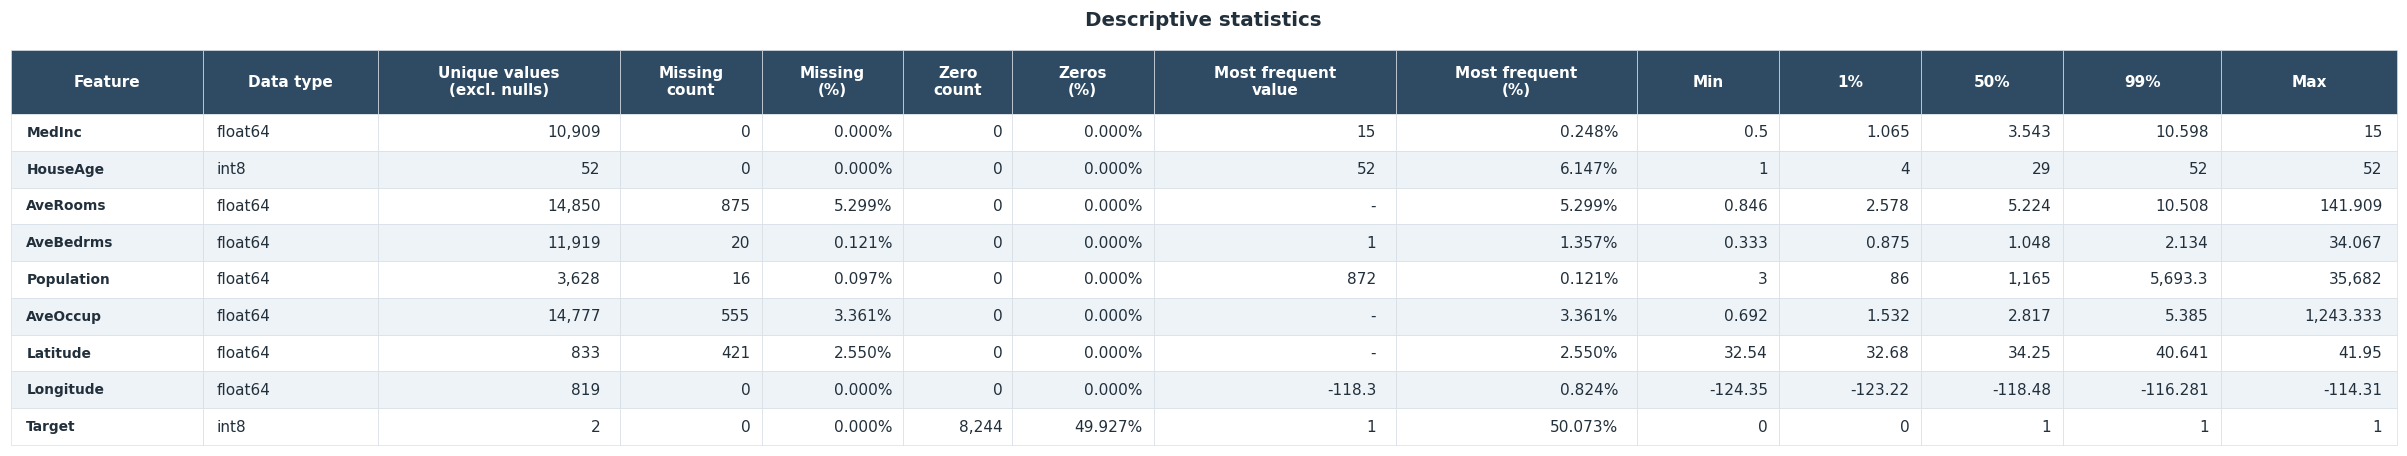

CSV -> profiling_examples/results/01_descriptive_statistics/A1_descriptive_statistics.csv
PNG -> profiling_examples/results/01_descriptive_statistics/A1_descriptive_statistics.png


In [5]:
descriptives = profiling.describe_data(Xy_train)

show_table(
    descriptives,
    "A1_descriptive_statistics",
    title="Descriptive statistics",
    folder=DESCRIBE_FOLDER,
)


In [6]:
# The same call with the optional arguments, displayed only (nothing saved).
profiling.describe_data(
    Xy_train,
    numeric_only=False,                                   # include Education
    drop_columns=["n_Zeros", "Perc. of Zeros", "1%", "99%"],
    round_columns={"Min": 2, "50%": 2, "Max": 2},
)


,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,1st Most Freq,Perc. of 1st Most Freq,Min,50%,Max
MedInc,float64,10909,0,0.000,15.0001,0.248,0.50,3.54,15.00
HouseAge,int8,52,0,0.000,52,6.147,1.00,29.00,52.00
AveRooms,float64,14850,875,5.299,NaN,5.299,0.85,5.22,141.91
AveBedrms,float64,11919,20,0.121,1.0,1.357,0.33,1.05,34.07
Population,float64,3628,16,0.097,872.0,0.121,3.00,"1,165.00","35,682.00"
AveOccup,float64,14777,555,3.361,NaN,3.361,0.69,2.82,"1,243.33"
Latitude,float64,833,421,2.550,NaN,2.550,32.54,34.25,41.95
Longitude,float64,819,0,0.000,-118.3,0.824,-124.35,-118.48,-114.31
Education,category,3,0,0.000,B,34.218,NaN,NaN,NaN
Target,int8,2,0,0.000,1,50.073,0.00,1.00,1.00


## A.2 Missing values

A value is missing when pandas reports it as null (`NaN`, `NaT`, `None`). Percentages are
relative to the **total** row count, not to the non-null count. `non_zero_only=False`
lists every column, which is what an audit trail wants.


,number_of_missing,percentage_of_missing
AveRooms,875,5.2992
AveOccup,555,3.3612
Latitude,421,2.5497
AveBedrms,20,0.1211
Population,16,0.0969


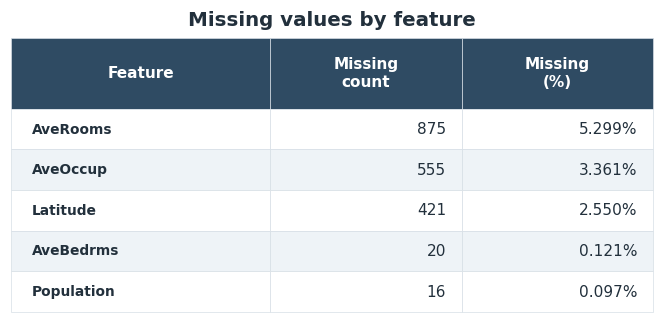

CSV -> profiling_examples/results/02_missing_values/A2_missing_values.csv
PNG -> profiling_examples/results/02_missing_values/A2_missing_values.png


In [7]:
missing = profiling.missing_count(Xy_train)

show_table(
    missing,
    "A2_missing_values",
    title="Missing values by feature",
    folder=MISSING_FOLDER,
)


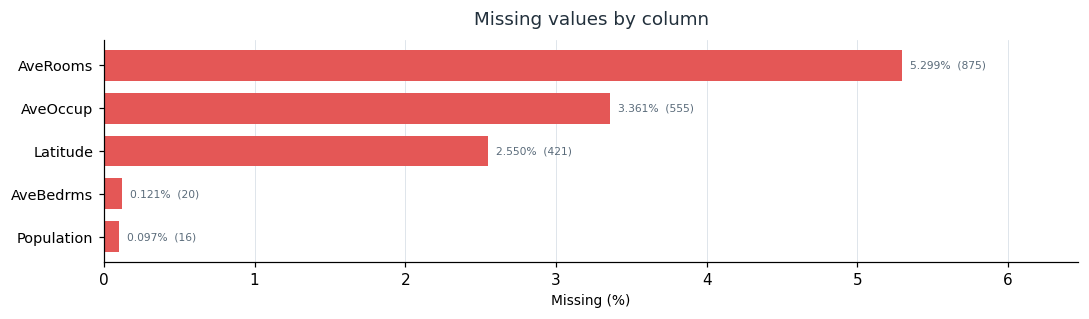

PNG -> profiling_examples/results/02_missing_values/A2_missing_values_chart.png


In [8]:
show_charts(
    profiling.plots.missing_values_figure(missing),
    profiling.missing_bar_figure(missing, fit_page=False),
    "A2_missing_values_chart",
    folder=MISSING_FOLDER,
)


## A.3 Correlation

Pearson on raw values, Spearman as Pearson on average ranks, Kendall as tau-b with tie
correction. Pairs are formed from rows where both features are present
(pairwise-complete), matching `DataFrame.corr`. A constant feature has an undefined
coefficient and is left blank rather than reported as zero.

`correlation_matrices` extracts the numeric block **once** and reuses it for every
method, which is why it beats calling `correlation_matrix` in a loop.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
MedInc,1.000,-0.151,0.643,-0.253,0.005,-0.047,-0.089,-0.008,0.570
HouseAge,-0.151,1.000,-0.231,-0.116,-0.283,-0.029,0.039,-0.157,0.064
AveRooms,0.643,-0.231,1.000,0.081,-0.105,0.021,0.128,-0.043,0.224
AveBedrms,-0.253,-0.116,0.081,1.000,0.029,-0.134,0.048,0.010,-0.105
Population,0.005,-0.283,-0.105,0.029,1.000,0.238,-0.119,0.119,-0.001
AveOccup,-0.047,-0.029,0.021,-0.134,0.238,1.000,-0.144,0.176,-0.242
Latitude,-0.089,0.039,0.128,0.048,-0.119,-0.144,1.000,-0.878,-0.121
Longitude,-0.008,-0.157,-0.043,0.010,0.119,0.176,-0.878,1.000,-0.089
Target,0.570,0.064,0.224,-0.105,-0.001,-0.242,-0.121,-0.089,1.000


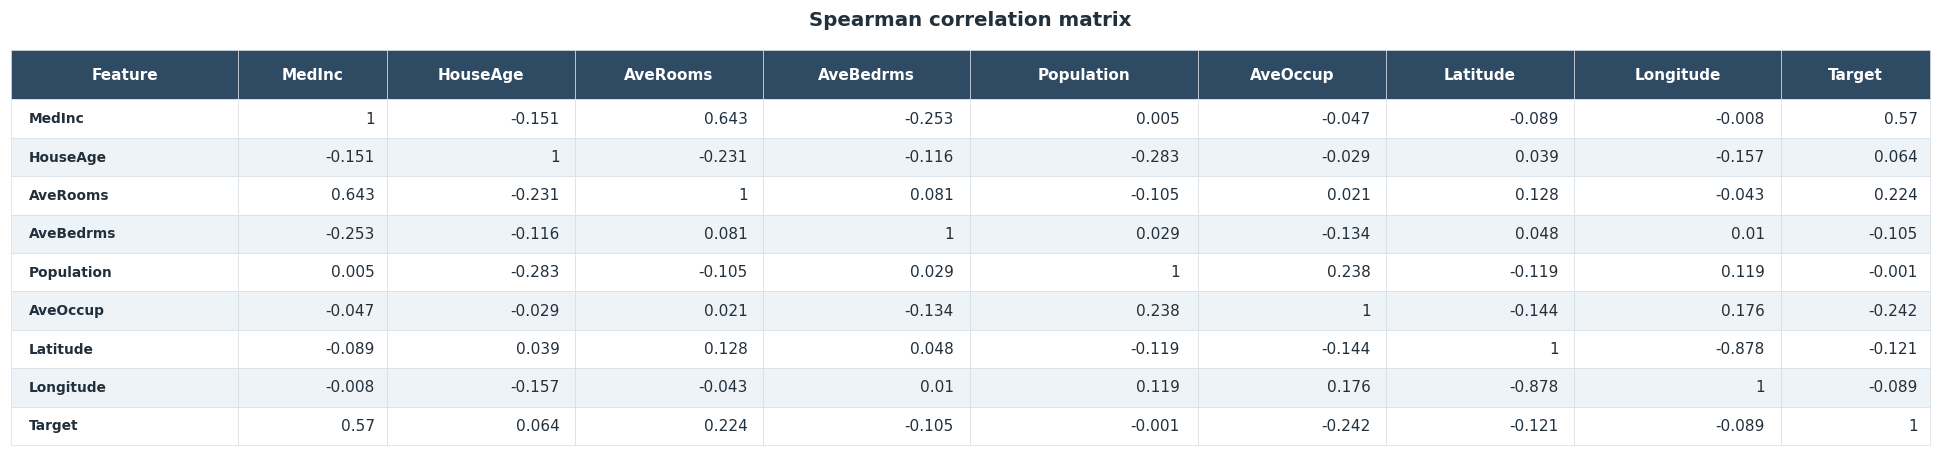

CSV -> profiling_examples/results/03_correlation/A3_correlation_spearman.csv
PNG -> profiling_examples/results/03_correlation/A3_correlation_spearman.png


In [9]:
matrices = profiling.correlation_matrices(Xy_train, ("pearson", "spearman"))

show_table(
    matrices["spearman"].round(3),
    "A3_correlation_spearman",
    title="Spearman correlation matrix",
    folder=CORRELATION_FOLDER,
)


,Feature 1,Feature 2,absolute spearman correlation values
0,Latitude,Longitude,0.877575
1,MedInc,AveRooms,0.642735
2,MedInc,Target,0.570478


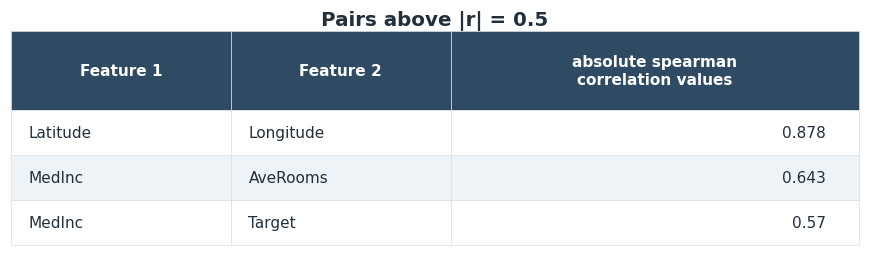

CSV -> profiling_examples/results/03_correlation/A3_top_correlations.csv
PNG -> profiling_examples/results/03_correlation/A3_top_correlations.png


In [10]:
top_pairs = profiling.top_absolute_correlations(
    matrices["spearman"], threshold=0.5, method_label="spearman"
)

show_table(
    top_pairs,
    "A3_top_correlations",
    title="Pairs above |r| = 0.5",
    show_index=False,
    folder=CORRELATION_FOLDER,
)


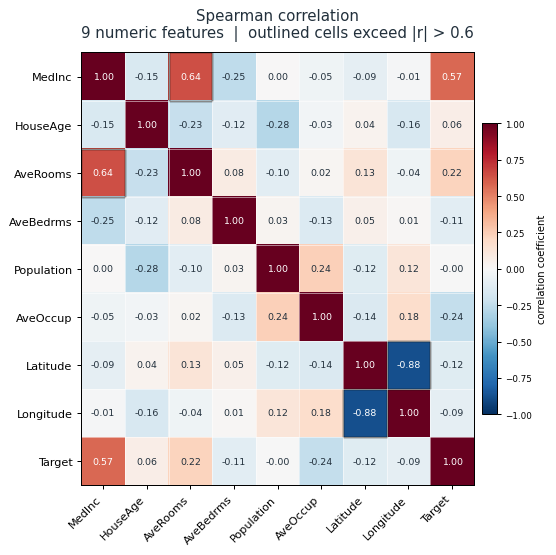

PNG -> profiling_examples/results/03_correlation/A3_correlation_heatmap.png


In [11]:
show_charts(
    profiling.plots.correlation_heatmap(matrices["spearman"], "spearman", threshold=0.6),
    profiling.heatmap_figure(matrices["spearman"], "spearman", threshold=0.6, fit_page=False),
    "A3_correlation_heatmap",
    folder=CORRELATION_FOLDER,
    dpi=90,
)


## A.4 Distributions

A distribution **summary** comes first, and every chart is drawn from it — never from the
raw column. `NumericDistribution` holds bin edges and counts, `CategoricalDistribution`
holds value counts with the long tail folded into `Other`. Both are a few hundred bytes
regardless of how many rows the file has, which is what keeps the interactive charts and
the exported charts identical.

`binning=QUANTILE` splits on empirical quantiles (equal occupancy, uneven widths);
`EQUAL_WIDTH` splits the range (even widths, uneven occupancy).


,feature,type,binning,bin,bin_label,bin_lower,bin_upper,count,percentage,n_missing,n_non_finite
0,MedInc,numeric,quantile,1,"[0.4999, 2.035]",0.499900,2.034713,2064,12.500000,0,0
1,MedInc,numeric,quantile,2,"(2.035, 2.57]",2.034713,2.570250,2064,12.500000,0,0
2,MedInc,numeric,quantile,3,"(2.57, 3.062]",2.570250,3.062500,2077,12.578731,0,0
3,MedInc,numeric,quantile,4,"(3.062, 3.543]",3.062500,3.543200,2051,12.421269,0,0
4,MedInc,numeric,quantile,5,"(3.543, 4.072]",3.543200,4.072038,2064,12.500000,0,0
...,...,...,...,...,...,...,...,...,...,...,...
64,Education,categorical,value-counts,1,B,NaN,NaN,5650,34.217539,0,0
65,Education,categorical,value-counts,2,C,NaN,NaN,5450,33.006298,0,0
66,Education,categorical,value-counts,3,A,NaN,NaN,5412,32.776163,0,0
67,Target,numeric,quantile,1,0,-0.500000,0.500000,8244,49.927326,0,0


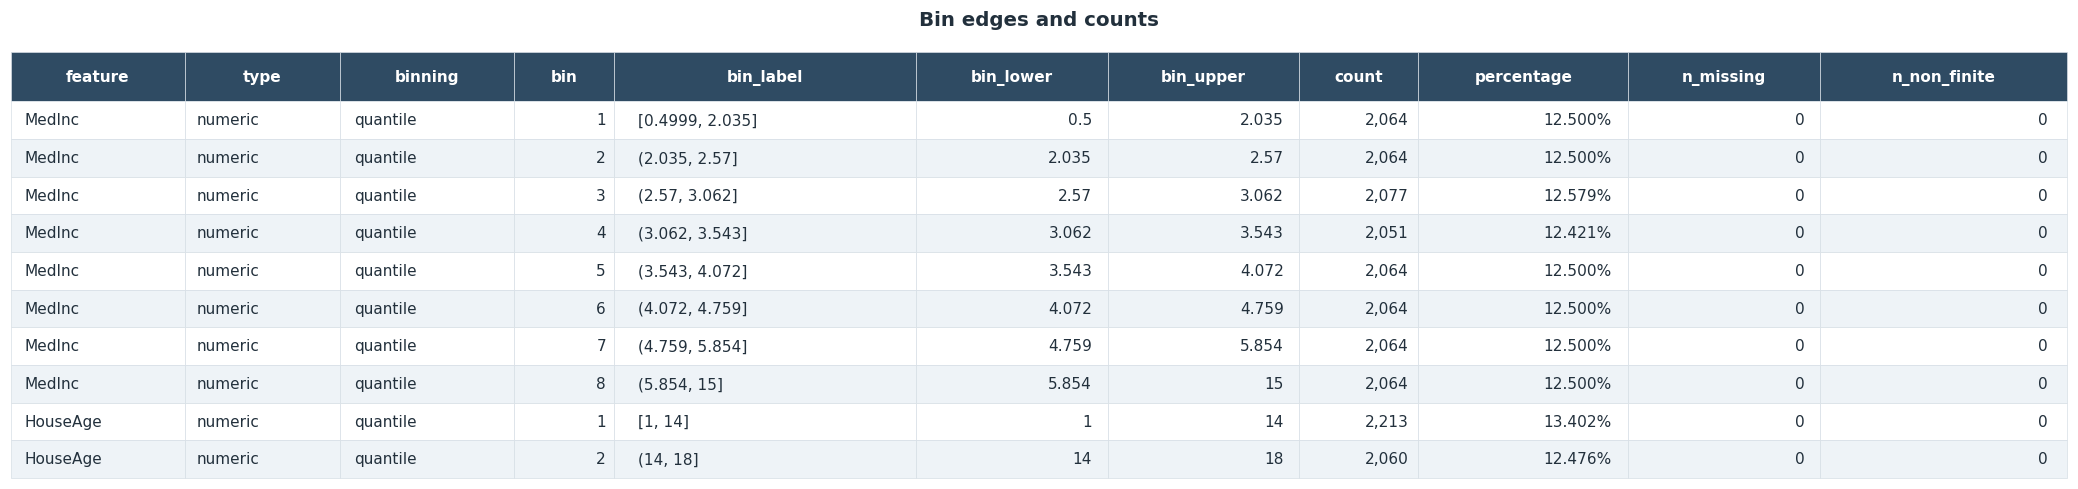

CSV -> profiling_examples/results/04_distributions/A4_distribution_bins.csv
PNG -> profiling_examples/results/04_distributions/A4_distribution_bins.png  (first 10 of 69 rows)


In [12]:
distributions = profiling.build_distributions(
    Xy_train, binning=profiling.QUANTILE, n_bins=8
)

show_table(
    profiling.distributions_to_frame(distributions),
    "A4_distribution_bins",
    title="Bin edges and counts",
    folder=DISTRIBUTION_FOLDER,
    rows_in_image=10,
    show_index=False,
)


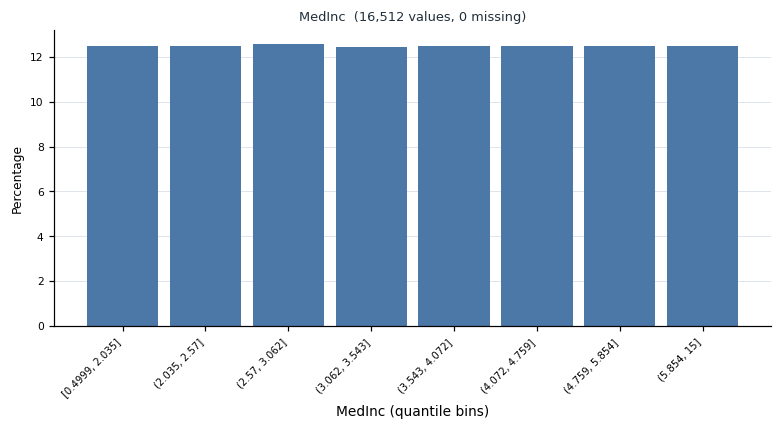

PNG -> profiling_examples/results/04_distributions/A4_histogram_MedInc.png


In [13]:
# A numeric feature.
show_charts(
    profiling.plots.histogram_figure(distributions["MedInc"], show_percentage=True),
    profiling.histogram_figure(distributions["MedInc"], show_percentage=True),
    "A4_histogram_MedInc",
    folder=DISTRIBUTION_FOLDER,
)


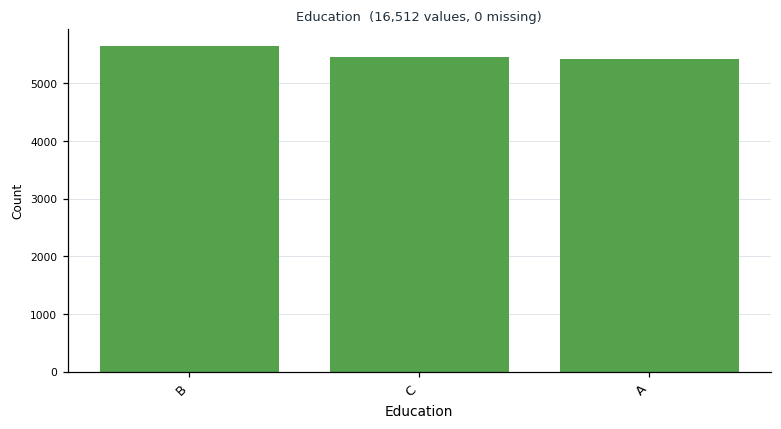

PNG -> profiling_examples/results/04_distributions/A4_histogram_Education.png


In [14]:
# A categorical feature: same call, same summary type, different renderer inside.
show_charts(
    profiling.plots.histogram_figure(distributions["Education"], color=profiling.PALETTE[2]),
    profiling.histogram_figure(distributions["Education"], color=profiling.PALETTE[2]),
    "A4_histogram_Education",
    folder=DISTRIBUTION_FOLDER,
)


In [15]:
# One PNG per feature — exactly what the Streamlit app writes into its export,
# because a nine-up grid cannot be split back into single features.
save_feature_charts(
    list(distributions.values()),
    lambda summary, index: profiling.histogram_figure(
        summary,
        color=profiling.PALETTE[index % len(profiling.PALETTE)],
        show_percentage=True,
    ),
    name="hist",
    folder=f"{DISTRIBUTION_FOLDER}/{CHART_FOLDER}",
)


[##----------------------]    1/10   MedInc                      

[####--------------------]    2/10   HouseAge                    

[#######-----------------]    3/10   AveRooms                    

[#########---------------]    4/10   AveBedrms                   

[############------------]    5/10   Population                  

...

[###################-----]    8/10   Longitude                   

[#####################---]    9/10   Education                   

[########################]   10/10   Target                      


10 chart(s) saved in profiling_examples/results/04_distributions/charts/


['C:\\Users\\parsa\\OneDrive\\Documents\\Studies\\projects\\eda_webapp\\profiling_examples\\results\\04_distributions\\charts\\hist_MedInc.png',
 'C:\\Users\\parsa\\OneDrive\\Documents\\Studies\\projects\\eda_webapp\\profiling_examples\\results\\04_distributions\\charts\\hist_HouseAge.png',
 'C:\\Users\\parsa\\OneDrive\\Documents\\Studies\\projects\\eda_webapp\\profiling_examples\\results\\04_distributions\\charts\\hist_AveRooms.png',
 'C:\\Users\\parsa\\OneDrive\\Documents\\Studies\\projects\\eda_webapp\\profiling_examples\\results\\04_distributions\\charts\\hist_AveBedrms.png',
 'C:\\Users\\parsa\\OneDrive\\Documents\\Studies\\projects\\eda_webapp\\profiling_examples\\results\\04_distributions\\charts\\hist_Population.png',
 'C:\\Users\\parsa\\OneDrive\\Documents\\Studies\\projects\\eda_webapp\\profiling_examples\\results\\04_distributions\\charts\\hist_AveOccup.png',
 'C:\\Users\\parsa\\OneDrive\\Documents\\Studies\\projects\\eda_webapp\\profiling_examples\\results\\04_distributions

## A.5 Outliers

Five-number summary plus Tukey fences: the box spans Q1 to Q3 and the whiskers reach the
most extreme observation still within 1.5 × IQR of the nearer quartile.

**Outlier counts are exact.** When a feature has more outliers than can be drawn legibly,
an evenly spaced subset is selected straight from the two tails without first
materialising every outlier — the summary still reports the true low, high and total
counts.


,feature,n_valid,n_missing,n_non_finite,min,lower_fence,q1,median,q3,upper_fence,max,mean,std,iqr,n_outliers_low,n_outliers_high,n_outliers,perc_outliers
0,MedInc,16512,0,0,0.4999,0.4999,2.5702,3.5432,4.7592,8.0409,15.0001,3.8803,1.9040,2.1889,0,540,540,3.2703
1,HouseAge,16512,0,0,1.0000,1.0000,18.0000,29.0000,37.0000,52.0000,52.0000,28.6483,12.5886,19.0000,0,0,0,0.0000
2,AveRooms,15637,875,0,0.8462,2.0569,4.4474,5.2238,6.0484,8.4484,141.9091,5.4350,2.5626,1.6011,35,374,409,2.6156
3,AveBedrms,16492,20,0,0.3333,0.8656,1.0056,1.0483,1.0992,1.2394,34.0667,1.0968,0.4894,0.0935,144,957,1101,6.6760
4,Population,16496,16,0,3.0000,3.0000,790.7500,1165.0000,1723.0000,3121.0000,35682.0000,1421.7902,1129.3021,932.2500,0,954,954,5.7832
5,AveOccup,15957,555,0,0.6923,1.1613,2.4292,2.8174,3.2799,4.5553,1243.3333,3.0366,10.0608,0.8507,5,546,551,3.4530
6,Latitude,16091,421,0,32.5400,32.5400,33.9300,34.2500,37.7100,41.9500,41.9500,35.6234,2.1374,3.7800,0,0,0,0.0000
7,Longitude,16512,0,0,-124.3500,-124.3500,-121.8000,-118.4800,-118.0000,-114.3100,-114.3100,-119.5661,2.0078,3.8000,0,0,0,0.0000
8,Target,16512,0,0,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.5007,0.5000,1.0000,0,0,0,0.0000


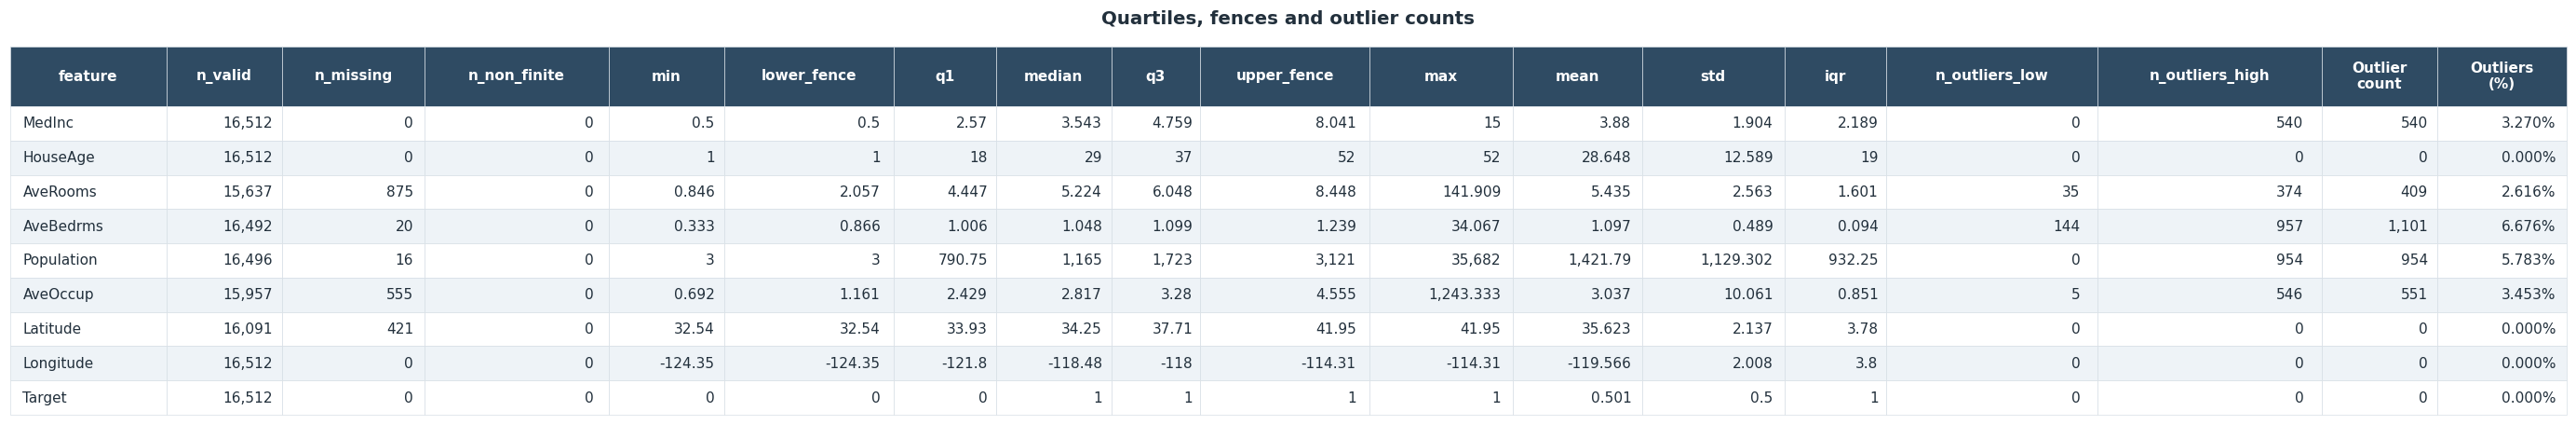

CSV -> profiling_examples/results/05_outliers/A5_outlier_statistics.csv
PNG -> profiling_examples/results/05_outliers/A5_outlier_statistics.png


In [16]:
boxes = profiling.build_box_summaries(Xy_train)

show_table(
    profiling.box_summaries_to_frame(boxes).round(4),
    "A5_outlier_statistics",
    title="Quartiles, fences and outlier counts",
    folder=OUTLIER_FOLDER,
    show_index=False,
)


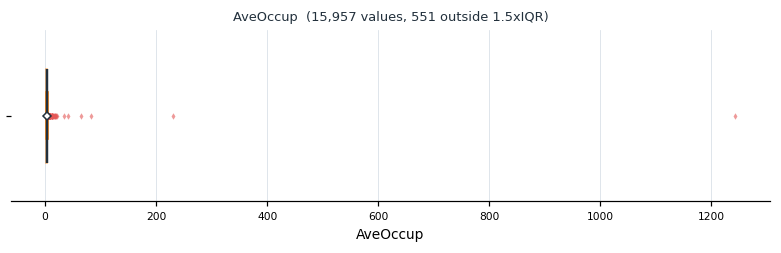

PNG -> profiling_examples/results/05_outliers/A5_box_AveOccup.png


In [17]:
show_charts(
    profiling.plots.box_figure(boxes["AveOccup"]),
    profiling.box_figure(boxes["AveOccup"], color=profiling.PALETTE[1]),
    "A5_box_AveOccup",
    folder=OUTLIER_FOLDER,
)


[##----------------------]    1/9    MedInc                      

[#####-------------------]    2/9    HouseAge                    

[########----------------]    3/9    AveRooms                    

[##########--------------]    4/9    AveBedrms                   

[#############-----------]    5/9    Population                  

[################--------]    6/9    AveOccup                    

[##################------]    7/9    Latitude                    

[#####################---]    8/9    Longitude                   

[########################]    9/9    Target                      


9 chart(s) saved in profiling_examples/results/05_outliers/charts/


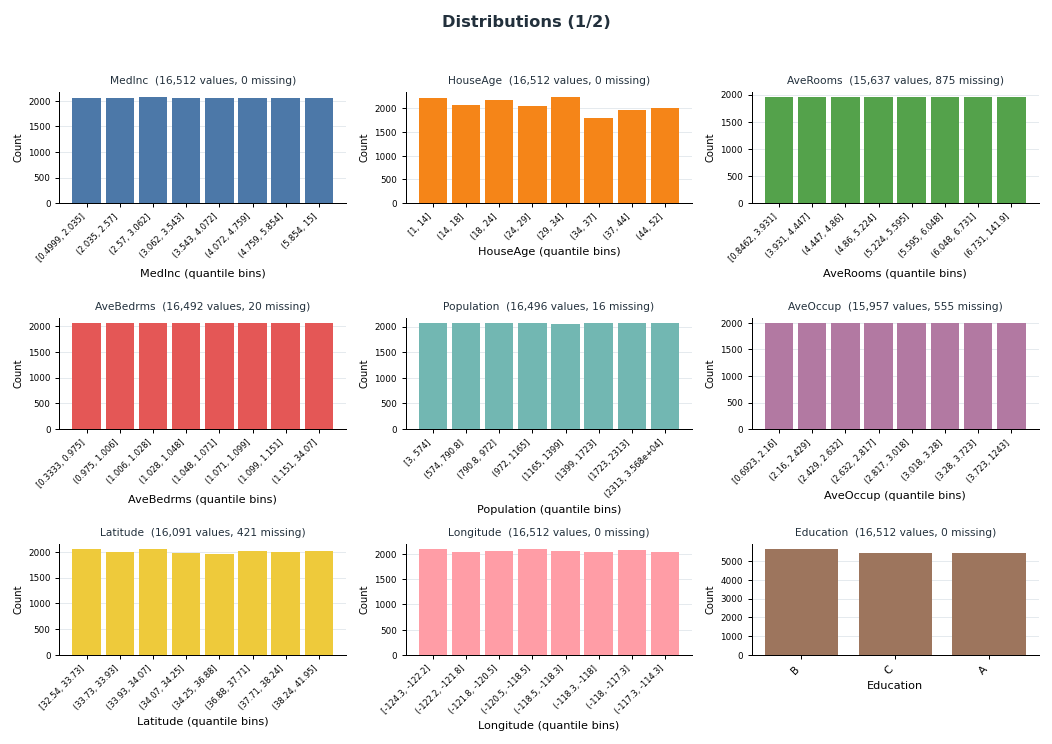

2 grid page(s) rendered (not saved — the per-feature PNGs above are)


In [18]:
save_feature_charts(
    list(boxes.values()),
    lambda summary, index: profiling.box_figure(
        summary, color=profiling.PALETTE[index % len(profiling.PALETTE)]
    ),
    name="box",
    folder=f"{OUTLIER_FOLDER}/{CHART_FOLDER}",
)

# The paginated grids are still available when you want a single page for a
# report; they are what the PDF is made of.
pages = profiling.histogram_grid_figures(list(distributions.values()), n_cols=3, n_rows=3)
display(Image(profiling.figure_to_png(pages[0], dpi=90)))
print(f"{len(pages)} grid page(s) rendered (not saved — the per-feature PNGs above are)")


## A.6 Sampling a large file

`sample_percent=` profiles a random share of the rows instead of all of them — the blunt,
whole-run control for a file too large to profile comfortably. **100 is the default and uses
everything.**

Two things make it safe to reason about:

- **One sample, one run.** The draw happens once, before anything is measured, so *every*
  table and chart in the result describes the same rows. Nothing is computed on the full
  data and nothing on a different subset.
- **Seeded.** The same percentage and `random_state` always profile the same rows, and the
  percentage, the rows used and the seed all land in `result.notes` and the exported
  metadata — so a sampled report says so on its face.

It composes with `correlation_max_rows`, which thins only the correlation step: use
`sample_percent` to make the whole run affordable, and `correlation_max_rows` when
correlation alone is the expensive part.

Distribution shapes and correlations survive sampling well. Exact counts do not — read row
counts and missing counts as belonging to the sample, not the file.


In [19]:
import time

# The same profile at three sampling rates.
rates = {}
for percent in (100, 25, 5):
    sampled_settings = profiling.ProfilingSettings(
        correlation_methods=("pearson",),
        sample_percent=percent,
    )
    started = time.perf_counter()
    sampled = profiling.run_profiling(
        Xy_train,
        sampled_settings,
        dataset_name=f"HousingData_TrainData.csv @ {percent}%",
    )
    medinc = sampled.describe.loc["MedInc"]
    rates[f"{percent}%"] = {
        "rows profiled": sampled.n_rows,
        "seconds": round(time.perf_counter() - started, 3),
        "MedInc median": round(float(pd.to_numeric(medinc.get("50%"), errors="coerce")), 4),
        "MedInc missing %": round(
            float(pd.to_numeric(medinc.get("Perc. of Missing"), errors="coerce")), 4
        ),
    }

sampling_effect = pd.DataFrame(rates).T
sampling_effect.index.name = "sample_percent"
display(sampling_effect)

# A sampled run says so, in the result and in the exported metadata.
print("\nnotes:")
for note in sampled.notes:
    print(" ", note)
print("\nmetadata sample_percent:", sampled.settings.as_dict()["sample_percent"])

# Seeded: the same percentage profiles the same rows every time.
again = profiling.run_profiling(
    Xy_train,
    profiling.ProfilingSettings(correlation_methods=("pearson",), sample_percent=5),
    dataset_name="repeat",
)
print("repeatable:", again.describe.equals(sampled.describe))


,rows profiled,seconds,MedInc median,MedInc missing %
sample_percent,,,,
100%,16512.0,0.036,3.5432,0.0
25%,4128.0,0.013,3.5605,0.0
5%,826.0,0.008,3.6144,0.0



notes:
  Every analysis in this run used a deterministic 5% subsample: 826 of 16,512 rows (seed 0).
  1 non-numeric feature(s) are excluded from correlation and box-plot analysis: Education

metadata sample_percent: 5
repeatable: True


---
# B. Two datasets side by side

The classic train-versus-test check. `combine_datasets` stacks the two frames into one and
adds a column recording where each row came from; that column is excluded from the feature
list, so it is never profiled as a feature — and it is exactly what you then group on.


In [20]:
combined = profiling.combine_datasets({"Train": Xy_train, "Test": Xy_test})

print("shape      ", combined.frame.shape)
print("tag column ", combined.tag_column)
print("sources    ", combined.sources)
combined.frame[combined.tag_column].value_counts()


shape       (20640, 11)
tag column  Dataset
sources     {'Train': 16512, 'Test': 4128}


Dataset
Train    16512
Test      4128
Name: count, dtype: int64

,segment,n_rows,share_of_rows_%,n_features,n_numeric_features,memory_mb,seconds
0,Train,16512,80.0,10,9,1.0553,0.0976
1,Test,4128,20.0,10,9,0.2640,0.0300


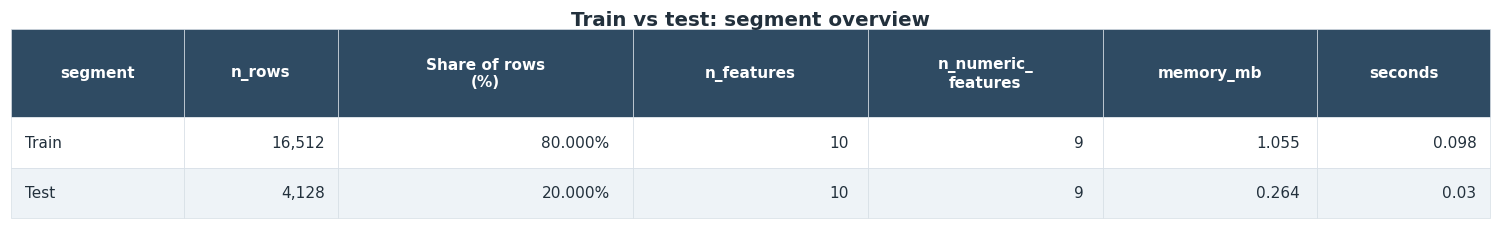

CSV -> profiling_examples/results/B_train_vs_test_overview.csv
PNG -> profiling_examples/results/B_train_vs_test_overview.png


In [21]:
settings = profiling.ProfilingSettings(
    correlation_methods=("spearman",),
    correlation_threshold=0.6,
    binning=profiling.QUANTILE,
    n_bins=8,
    show_percentage=True,
    random_state=0,
)

train_vs_test = profiling.run_segmented_profiling(
    {"Train": Xy_train, "Test": Xy_test},
    settings,
    by="Dataset",
    dataset_name="HousingData",
)

show_table(
    train_vs_test.segment_overview(),
    "B_train_vs_test_overview",
    title="Train vs test: segment overview",
    show_index=False,
)


segment,Test,Train,shift_%
feature,,,
AveBedrms,1.0499,1.0483,0.15
AveOccup,2.8318,2.8174,0.51
AveRooms,5.2332,5.2238,0.18
HouseAge,28.5000,29.0000,-1.72
Latitude,34.2900,34.2500,0.12
Longitude,-118.5400,-118.4800,0.05
MedInc,3.5053,3.5432,-1.07
Population,1171.0000,1165.0000,0.52
Target,0.0000,1.0000,-100.00


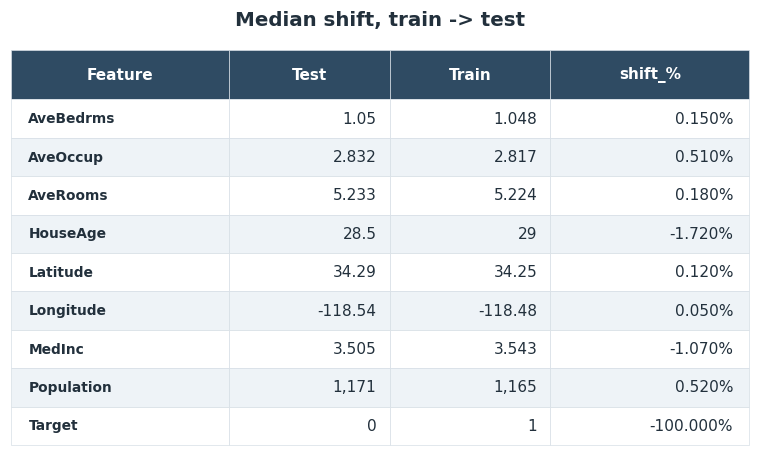

CSV -> profiling_examples/results/B_median_shift.csv
PNG -> profiling_examples/results/B_median_shift.png


In [22]:
# The median of every feature in each dataset, plus the shift between them.
medians = train_vs_test.describe_comparison().pivot(
    index="feature", columns="segment", values="50%"
)
medians["shift_%"] = ((medians["Test"] - medians["Train"]) / medians["Train"] * 100).round(2)

show_table(medians.round(4), "B_median_shift", title="Median shift, train -> test")


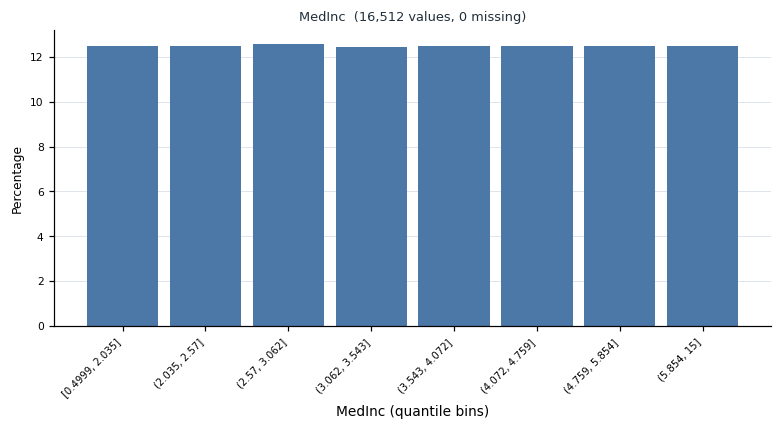

PNG -> profiling_examples/results/B_histogram_MedInc_Train.png


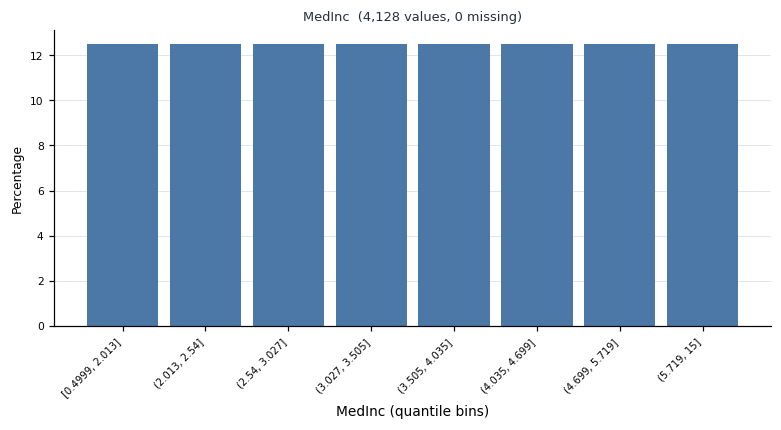

PNG -> profiling_examples/results/B_histogram_MedInc_Test.png


In [23]:
# The same feature in both datasets: two summaries, two charts, two saved PNGs.
for label in train_vs_test.keys:
    summary = train_vs_test[label].distributions["MedInc"]
    show_charts(
        profiling.plots.histogram_figure(summary, show_percentage=True),
        profiling.histogram_figure(summary, show_percentage=True),
        f"B_histogram_MedInc_{label}",
    )


---
# C. Profiling in segments

The capability the dashboard does not expose: split the data, then run the *identical*
settings on every segment — that is what keeps the numbers comparable.

| call | split |
|---|---|
| `make_grouping(df, "Education")` | one segment per distinct value |
| `make_grouping(df, "HouseAge", bins=[(1, 20), (20, 50)])` | explicit right-closed intervals |
| `make_grouping(df, "HouseAge", n_bins=4)` | four equal-width intervals |
| `make_grouping(df, "HouseAge", n_quantiles=4)` | four equal-frequency intervals |

A `Grouping` holds only row positions, never data, so building one is cheap and the same
grouping can feed several analyses.


values       Education  ['Education=A', 'Education=B', 'Education=C']
intervals    HouseAge   ['HouseAge=(1, 20]', 'HouseAge=(20, 50]']
equal-width  HouseAge   ['HouseAge=(0.949, 13.75]', 'HouseAge=(13.75, 26.5]', 'HouseAge=(26.5, 39.25]', 'HouseAge=(39.25, 52.0]']
quantile     HouseAge   ['HouseAge=(0.999, 18.0]', 'HouseAge=(18.0, 29.0]', 'HouseAge=(29.0, 37.0]', 'HouseAge=(37.0, 52.0]']

1,057 rows fall outside the explicit intervals and belong to no segment


,segment,label,n_rows,share_of_rows_%
0,"(0.999, 18.0]","HouseAge=(0.999, 18.0]",4273,25.8781
1,"(18.0, 29.0]","HouseAge=(18.0, 29.0]",4230,25.6177
2,"(29.0, 37.0]","HouseAge=(29.0, 37.0]",4036,24.4428
3,"(37.0, 52.0]","HouseAge=(37.0, 52.0]",3973,24.0613


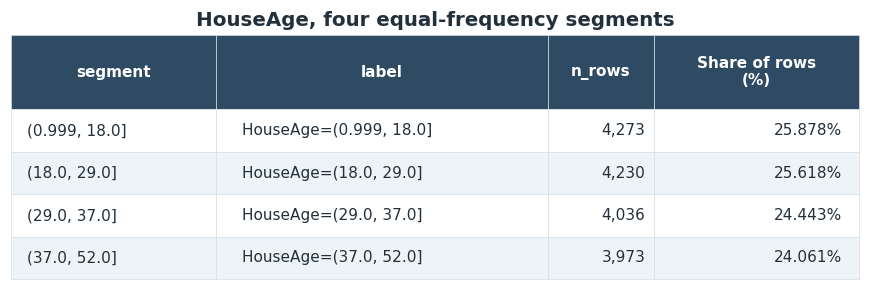

CSV -> profiling_examples/results/C_segments_by_quantile.csv
PNG -> profiling_examples/results/C_segments_by_quantile.png


In [24]:
by_value = profiling.make_grouping(Xy_train, "Education")
by_interval = profiling.make_grouping(Xy_train, "HouseAge", bins=[(1, 20), (20, 50)])
by_width = profiling.make_grouping(Xy_train, "HouseAge", n_bins=4)
by_quantile = profiling.make_grouping(Xy_train, "HouseAge", n_quantiles=4)

for grouping in (by_value, by_interval, by_width, by_quantile):
    print(f"{grouping.method:<12} {grouping.grouping_var:<10} {grouping.labels}")
print(f"\n{by_interval.n_rows_unassigned:,} rows fall outside the explicit intervals "
      "and belong to no segment")

show_table(
    by_quantile.to_frame(),
    "C_segments_by_quantile",
    title="HouseAge, four equal-frequency segments",
    show_index=False,
)


grouping HouseAge (quantile)
segments 4   total 0.12 s


,segment,n_rows,share_of_rows_%,n_features,n_numeric_features,memory_mb,seconds
0,"(0.999, 18.0]",4273,25.8781,10,9,0.2733,0.0296
1,"(18.0, 29.0]",4230,25.6177,10,9,0.2705,0.0311
2,"(29.0, 37.0]",4036,24.4428,10,9,0.2581,0.0354
3,"(37.0, 52.0]",3973,24.0613,10,9,0.2541,0.0269


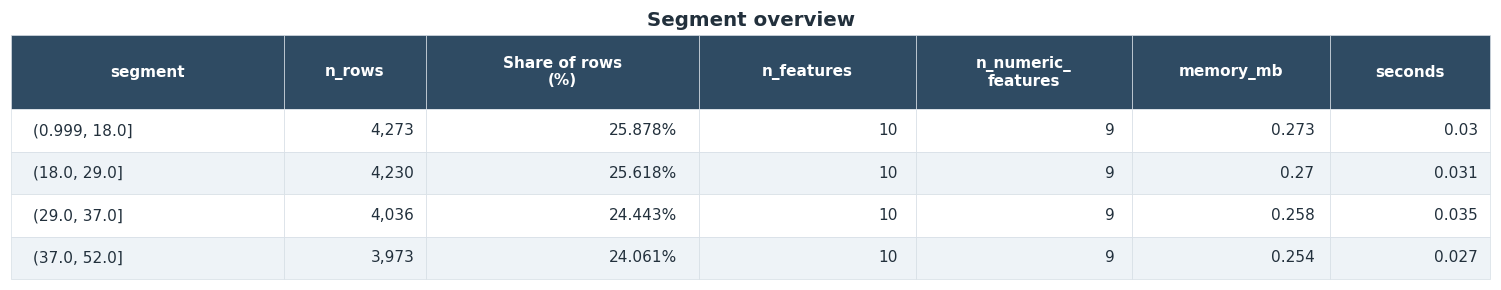

CSV -> profiling_examples/results/C_segment_overview.csv
PNG -> profiling_examples/results/C_segment_overview.png


In [25]:
segmented = profiling.run_segmented_profiling(
    Xy_train,
    settings,
    by="HouseAge",
    n_quantiles=4,
    dataset_name="HousingData_TrainData.csv",
)

print(f"grouping {segmented.grouping_var} ({segmented.method})")
print(f"segments {len(segmented)}   total {segmented.total_seconds:.2f} s")

show_table(
    segmented.segment_overview(),
    "C_segment_overview",
    title="Segment overview",
    show_index=False,
)


The comparison methods return long frames with `segment` in front — the shape that pivots,
plots and diffs cleanly. Each segment is also a plain `ProfilingResult`, so anything that
renders or exports a single run handles one segment with no second code path.


segment,"(0.999, 18.0]","(18.0, 29.0]","(29.0, 37.0]","(37.0, 52.0]"
feature,,,,
AveBedrms,1.061,1.050,1.038,1.046
AveOccup,2.836,2.832,2.903,2.673
AveRooms,5.705,5.257,5.133,4.883
HouseAge,14.000,24.000,34.000,45.000
Latitude,34.720,34.280,34.130,34.350
Longitude,-119.030,-118.750,-118.350,-118.990
MedInc,3.961,3.505,3.572,3.165
Population,1440.000,1333.000,1098.000,940.000
Target,0.000,1.000,1.000,1.000


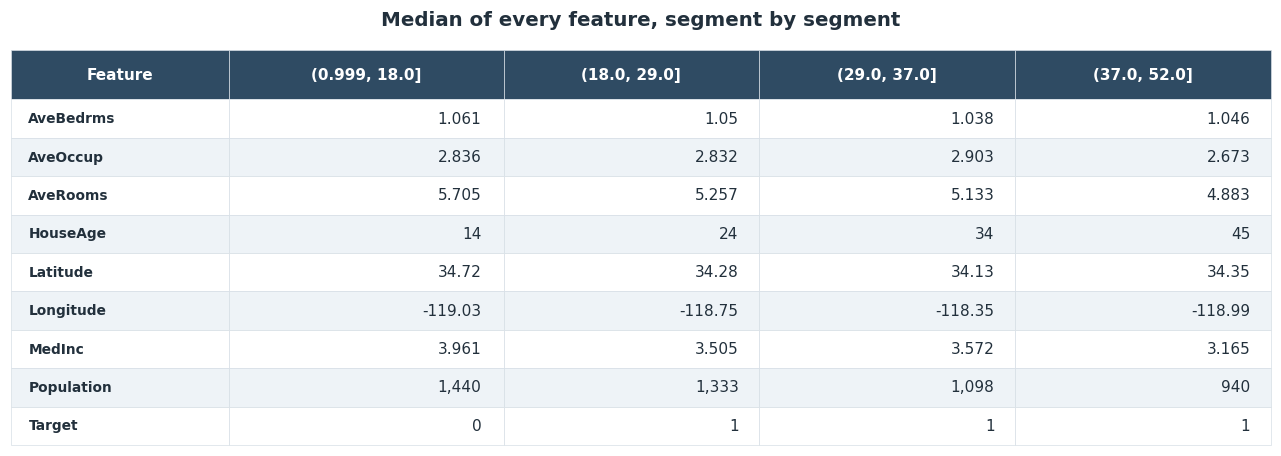

CSV -> profiling_examples/results/C_median_by_segment.csv
PNG -> profiling_examples/results/C_median_by_segment.png


In [26]:
show_table(
    segmented.describe_comparison().pivot(index="feature", columns="segment", values="50%").round(3),
    "C_median_by_segment",
    title="Median of every feature, segment by segment",
)


,segment,feature,median,iqr,n_outliers,perc_outliers
0,"(0.999, 18.0]",MedInc,3.960700,2.373200,92,2.1531
1,"(0.999, 18.0]",HouseAge,14.000000,6.000000,0,0.0000
2,"(0.999, 18.0]",AveRooms,5.705152,1.707730,143,3.5291
3,"(0.999, 18.0]",AveBedrms,1.061407,0.107416,405,9.4981
4,"(0.999, 18.0]",Population,1440.000000,1303.000000,281,6.5854
5,"(0.999, 18.0]",AveOccup,2.836257,0.795739,100,2.4195
6,"(0.999, 18.0]",Latitude,34.720000,4.030000,0,0.0000
7,"(0.999, 18.0]",Longitude,-119.030000,3.790000,0,0.0000
8,"(0.999, 18.0]",Target,0.000000,1.000000,0,0.0000
9,"(18.0, 29.0]",MedInc,3.505400,2.255125,124,2.9314


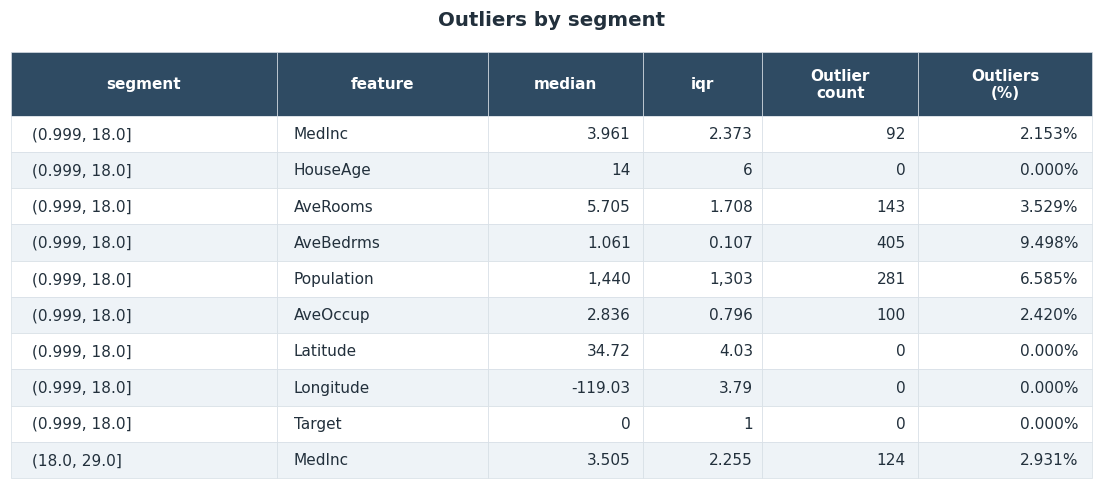

CSV -> profiling_examples/results/C_outliers_by_segment.csv
PNG -> profiling_examples/results/C_outliers_by_segment.png  (first 10 of 36 rows)


In [27]:
show_table(
    segmented.box_comparison()[
        ["segment", "feature", "median", "iqr", "n_outliers", "perc_outliers"]
    ],
    "C_outliers_by_segment",
    title="Outliers by segment",
    rows_in_image=10,
    show_index=False,
)


`correlation_comparison` is built from the **full** matrices, so every pair is present in
every segment and a row can be read across. Sorted by spread, the top rows are the
relationships that appear, vanish or flip sign between segments — the interesting ones.


,Feature 1,Feature 2,"(0.999, 18.0]","(18.0, 29.0]","(29.0, 37.0]","(37.0, 52.0]",max_abs_difference
0,Latitude,Longitude,-0.879,-0.891,-0.847,-0.814,0.077
1,MedInc,AveRooms,0.593,0.643,0.662,0.621,0.069
2,MedInc,Target,0.594,0.583,0.592,0.610,0.027


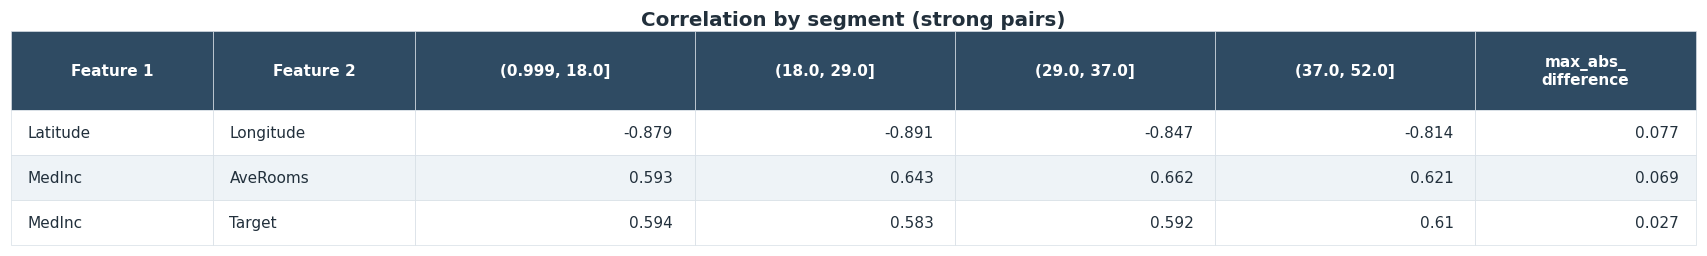

CSV -> profiling_examples/results/C_correlation_by_segment.csv
PNG -> profiling_examples/results/C_correlation_by_segment.png


In [28]:
show_table(
    segmented.correlation_comparison("spearman", min_abs=0.5).round(3),
    "C_correlation_by_segment",
    title="Correlation by segment (strong pairs)",
    show_index=False,
)


segment: HousingData_TrainData.csv [HouseAge=(0.999, 18.0]]


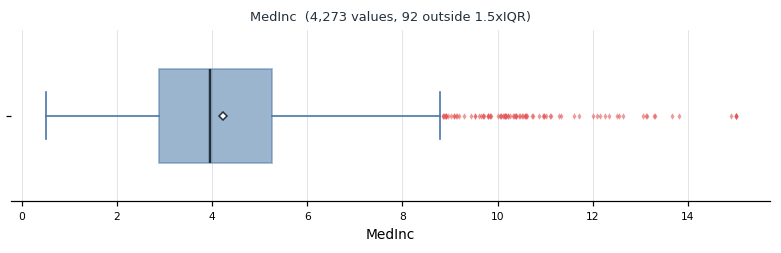

PNG -> profiling_examples/results/C_box_MedInc_first_segment.png


In [29]:
# One segment, drawn exactly like the whole dataset was in section A.
first = segmented[segmented.keys[0]]
print("segment:", first.dataset_name)

show_charts(
    profiling.plots.box_figure(first.box_summaries["MedInc"]),
    profiling.box_figure(first.box_summaries["MedInc"]),
    "C_box_MedInc_first_segment",
)


---
# D. The whole profile in one call

`ProfilingSettings` captures everything that influences the numbers, and the whole object
is written into the exported metadata — so a report can always be traced back to the
configuration that produced it.


In [30]:
result = profiling.run_profiling(
    Xy_train,
    settings,
    dataset_name="HousingData_TrainData.csv",
    dtype_labels=train.original_dtypes,
    source_info={
        "parser": train.parser,
        "delimiter": train.delimiter,
        "token": train.token,
        "memory_saved_mb": train.memory_saved_mb,
    },
    progress=lambda label, fraction: print(f"  {fraction:5.0%}  {label}"),
)

print()
print(f"rows             {result.n_rows:,}")
print(f"numeric features {len(result.numeric_features)}")
print(f"in memory        {result.memory_mb:.2f} MB")
print(f"total            {result.total_seconds:.2f} s")
print("timings          ", {key: round(value, 3) for key, value in result.timings.items()})
print("notes            ", result.notes)


    20%  Descriptive statistics
    40%  Missing values


    60%  Correlation analysis
    80%  Distributions
   100%  Box plots
   100%  Done

rows             16,512
numeric features 9
in memory        0.93 MB
total            0.11 s
timings           {'descriptive_statistics': 0.01, 'missing_values': 0.002, 'correlation': 0.08, 'distributions': 0.008, 'box_plots': 0.008}
notes             ['1 non-numeric feature(s) are excluded from correlation and box-plot analysis: Education']


,Feature 1,Feature 2,absolute spearman correlation values
0,Latitude,Longitude,0.877575
1,MedInc,AveRooms,0.642735


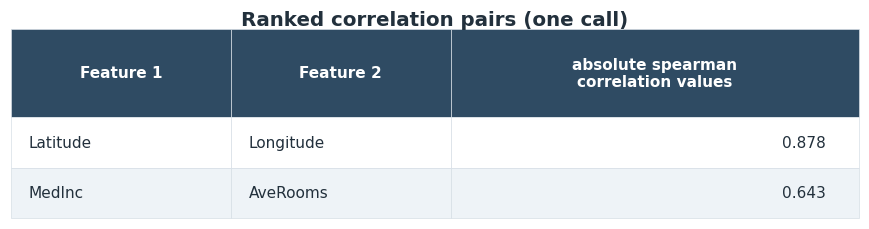

CSV -> profiling_examples/results/D_top_correlations.csv
PNG -> profiling_examples/results/D_top_correlations.png


In [31]:
# Everything section A computed by hand is on the result object.
show_table(
    result.top_correlations["spearman"],
    "D_top_correlations",
    title="Ranked correlation pairs (one call)",
    show_index=False,
)


In [32]:
# The run is self-describing: metadata() is JSON-serialisable and records the dataset,
# the settings, the timings and the library versions.
metadata = profiling.storage.write_text(
    address("D_metadata.json"),
    json.dumps(result.metadata(), indent=2, default=str),
)
print(f"JSON -> {saved(metadata)}")
print(json.dumps(result.metadata()["settings"], indent=2, default=str))


JSON -> profiling_examples/results/D_metadata.json
{
  "selected_features": [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude",
    "Education",
    "Target"
  ],
  "n_selected_features": 10,
  "include_describe": true,
  "include_missing": true,
  "include_correlation": true,
  "include_histograms": true,
  "include_box_plots": true,
  "correlation_methods": [
    "spearman"
  ],
  "correlation_threshold": 0.6,
  "correlation_max_rows": null,
  "sample_percent": 100.0,
  "binning": "quantile",
  "n_bins": 8,
  "max_categories": 30,
  "histogram_units": "percentage",
  "random_state": 0
}


---
# E. Export a full report

Three shapes of the same bundle: a paginated PDF, a ZIP archive, or a plain folder.
`build_zip` and `write_report_dir` share one definition of the contents, so an unpacked
archive and a written folder are the same tree.

All three land in `SAVE_DIR`, and all three are equally happy with a DBFS or ADLS address.


In [33]:
pdf_bytes = profiling.build_pdf(result)
pdf = profiling.storage.write_bytes(address("E_report.pdf"), pdf_bytes)
print(f"PDF -> {saved(pdf)}  ({len(pdf_bytes) / 1024:,.0f} KB)")

# Pass the rendered PDF in so the ZIP does not have to render it again.
zip_bytes = profiling.build_zip(result, pdf_bytes=pdf_bytes, include_individual_charts=False)
archive = profiling.storage.write_bytes(
    address(f"{profiling.suggested_basename(result)}.zip"), zip_bytes
)
print(f"ZIP -> {saved(archive)}  ({len(zip_bytes) / 1024:,.0f} KB)")


PDF -> profiling_examples/results/E_report.pdf  (122 KB)


ZIP -> profiling_examples/results/HousingData_TrainData_profiling_20260730_170305.zip  (825 KB)


In [34]:
written = profiling.write_report_dir(
    result,
    address("E_report_folder"),
    include_pdf=False,
    include_individual_charts=False,
)
print(f"{len(written)} files written to {saved(address('E_report_folder'))}/\n")
for path in written[:12]:
    print("   ", saved(path))
print("    ...")


17 files written to profiling_examples/results/E_report_folder/

    profiling_examples/results/E_report_folder/metadata.json
    profiling_examples/results/E_report_folder/01_descriptive_statistics/descriptive_statistics.csv
    profiling_examples/results/E_report_folder/01_descriptive_statistics/descriptive_statistics.png
    profiling_examples/results/E_report_folder/02_missing_values/missing_values_all_columns.csv
    profiling_examples/results/E_report_folder/02_missing_values/missing_values_affected_columns.csv
    profiling_examples/results/E_report_folder/02_missing_values/missing_values.png
    profiling_examples/results/E_report_folder/03_correlation/correlation_matrix_spearman.csv
    profiling_examples/results/E_report_folder/03_correlation/top_correlations_spearman.csv
    profiling_examples/results/E_report_folder/03_correlation/correlation_heatmap_spearman.png
    profiling_examples/results/E_report_folder/03_correlation/correlations.xlsx
    profiling_examples/results/E

In [35]:
# One bundle folder per segment, plus a 00_comparison/ folder holding the tables that
# span every segment: the grouping is visible from the file tree alone.
tree = profiling.write_segmented_report_dir(
    segmented,
    address("E_segmented_report"),
    include_pdf=False,
    include_individual_charts=False,
)
for key, paths in tree.items():
    print(f"{key:<28} {len(paths):>3} files")


00_comparison                  9 files
(0.999, 18.0]                 17 files
(18.0, 29.0]                  17 files
(29.0, 37.0]                  17 files
(37.0, 52.0]                  17 files


---
# F. Preparation: collapsing one-hot encodings

Profiling a wide block of 0/1 dummies says very little; profiling the one categorical
column they encode says a lot. Each dummy group is replaced, in the position of its first
member, by a single column. The input frame is never modified — a copy comes back.


In [36]:
encoded = profiling.load_table(DATA_DIR / "HousingData_OHE_TrainData.csv").frame
print("before:", list(encoded.columns))

# "auto" infers the groups from the separator in the column names.
merged = profiling.merge_one_hot_encoded_columns(encoded, separator="_")
print("after :", list(merged.columns))

# strip_prefix drops the "<feature><separator>" part of each value.
stripped = profiling.merge_one_hot_encoded_columns(
    encoded,
    {"Education": ["Education_A", "Education_B", "Education_C"]},
    separator="_",
    strip_prefix=True,
)

pd.DataFrame(
    {
        "merged": merged["Education"].value_counts(),
        "merged, prefix stripped": stripped["Education"].value_counts(),
    }
)


before: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Education_A', 'Education_B', 'Education_C', 'Target']
after : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Education', 'Target']


,merged,"merged, prefix stripped"
Education,,
A,NaN,5034.0
B,NaN,6028.0
C,NaN,5450.0
Education_A,5034.0,NaN
Education_B,6028.0,NaN
Education_C,5450.0,NaN


---
# H. This notebook and the Streamlit app

Both run the **same engine**, so the numbers cannot disagree. What differs:

| | The app (`streamlit run app.py`) | This notebook |
|---|---|---|
| Describe, missing, correlation, distributions, outliers | ✔ | ✔ |
| One chart per feature, saved as PNG | ✔ | ✔ (`save_feature_charts`) |
| PDF / ZIP / folder export | ✔ | ✔ |
| **Segmentation** — one profile per segment | — | ✔ (sections C and E) |
| Comparing two datasets by tagging and grouping | — | ✔ (section B) |
| Collapsing one-hot encodings before profiling | — | ✔ (section F) |
| Reusing a `Grouping` across analyses | — | ✔ |
| Feeding results into your own code | — | ✔ — every result is a DataFrame |

Everything above is plain Python: no Streamlit, no globals, nothing that needs a browser.


---
# G. Databricks, DBFS and ADLS

Nothing in this notebook has to change to run on a cluster; only `SAVE_DIR` does.

```python
SAVE_DIR = "abfss://container@account.dfs.core.windows.net/eda_studio/profiling"
profiling.set_output_dir(SAVE_DIR)
```

Why that works behind a corporate firewall:

* **every file is finished before it is written.** Tables are serialised to bytes and
  figures rendered to PNG in memory, then written with a single call — nothing is opened
  once and appended to in pieces, which is the pattern a locked-down ADLS destination
  refuses.
* **cloud writes go through `dbutils.fs`.** The driver performs one `cp` of a staged
  file, so the cluster's own credentials are used and Python never opens a connection to
  the storage account.
* **remote addresses are never run through `pathlib`.** `Path("abfss://a/b")` silently
  collapses the double slash; `profiling.storage` handles URIs as text.

Spark frames are supported directly, and nothing Spark-related is imported until one is
actually passed in:

```python
segmented = profiling.run_segmented_profiling(spark_df, settings, by="age", n_quantiles=4)
profiling.write_segmented_report_dir(segmented, SAVE_DIR + "/segmented")
```

`make_grouping` then bucketises **in Spark** (`Bucketizer` for `bins`/`n_bins`,
`QuantileDiscretizer` for `n_quantiles`) instead of pulling the grouping column onto the
driver, `combine_datasets` concatenates with `pyspark.pandas`, and
`run_segmented_profiling` materialises one segment at a time, so the driver never holds
more than a single segment.


---
## What was saved

Everything this notebook wrote is in one place.


In [37]:
if not profiling.storage.is_remote(SAVE_DIR):
    files = sorted(path for path in Path(SAVE_DIR).rglob("*") if path.is_file())
    summary = (
        pd.Series([path.suffix.lower() or "(none)" for path in files], name="files")
        .value_counts()
        .rename_axis("extension")
        .reset_index(name="files")
    )
    total_mb = sum(path.stat().st_size for path in files) / (1024 * 1024)
    print(f"{len(files)} files, {total_mb:.1f} MB, under {saved(SAVE_DIR)}/")
    display(summary)
else:
    print("Saved to", SAVE_DIR)


153 files, 9.4 MB, under profiling_examples/results/


,extension,files
0,.png,76
1,.csv,57
2,.json,7
3,.xlsx,5
4,.txt,5
5,.zip,2
6,.pdf,1


---
## Cheat sheet

```python
import profiling

profiling.set_output_dir("profiling_examples/results")   # one default for everything
profiling.output_dir()                                   # where that is now

# load and prepare
loaded = profiling.load_table("data.csv")                # -> LoadedData
frame = profiling.merge_one_hot_encoded_columns(loaded.frame, separator="_")
both = profiling.combine_datasets({"Train": tr, "Test": te})

# analyse, piece by piece
profiling.describe_data(frame)
profiling.missing_count(frame)
profiling.correlation_matrices(frame, ("pearson", "spearman"))
profiling.build_distributions(frame, binning=profiling.QUANTILE, n_bins=8)
profiling.build_box_summaries(frame)

# ...or in one call
settings = profiling.ProfilingSettings(correlation_methods=("spearman",))
result = profiling.run_profiling(frame, settings, dataset_name="data.csv")

# ...or once per segment
segmented = profiling.run_segmented_profiling(frame, settings, by="age", n_quantiles=4)
segmented.describe_comparison()
segmented.correlation_comparison("spearman")

# render and export: save=True uses the standard folder, save=<address> anything else
profiling.df_to_img(result.describe, save=True)
profiling.histogram_figure(summary, save="reports/hist.png")
profiling.build_pdf(result)                              # -> bytes
profiling.build_zip(result)                              # -> bytes
profiling.write_report_dir(result)                       # -> [addresses]
profiling.write_segmented_report_dir(segmented)          # -> {segment: [addresses]}
```
